#                     Predicting Stock Market

# Installing Pyspark

In [44]:
!pip install pyspark

# Importing And Installing All the necessary libraries files

In [54]:
import nltk
nltk.download("vader_lexicon")
import  pyspark
from pyspark.sql.functions import input_file_name
from pyspark.sql import SparkSession
from pyspark.sql.types import *
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf
from pyspark.sql.types import DoubleType
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql.functions import avg, col, collect_list, udf
from pyspark.sql.types import DoubleType
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.sql import SparkSession
from pyspark.ml.evaluation import RegressionEvaluator
from nltk.sentiment.vader import SentimentIntensityAnalyzer


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

# Creating Spark Session 

In [45]:

# Create SparkSession
spark = SparkSession.builder.master("local[*]") \
    .config("spark.network.timeout", "2000s") \
    .config("spark.executor.heartbeatInterval", "60s") \
  .config("spark.worker.timeout", "2000s") \
    .appName("Najam") \
    .getOrCreate()

df = spark.read.csv("stocks.csv", header=True, inferSchema=True)

# Preprocessing steps

In [48]:
df.printSchema()
df=df.limit(1000)
df.show(5)

numerical_columns = ['open', 'high', 'low', 'close', 'adjclose', 'volume']
for column in numerical_columns:
    mean_value = df.select(mean(column)).first()[0]
    df = df.na.fill({column: mean_value})

df = df.na.fill({'ticker': 'UNKNOWN'})
df = df.select('Date', 'open', 'high', 'low', 'close', 'adjclose', 'volume', 'ticker')

df.show(5)


root
 |-- Date: date (nullable = true)
 |-- open: double (nullable = false)
 |-- high: double (nullable = false)
 |-- low: double (nullable = false)
 |-- close: double (nullable = false)
 |-- adjclose: double (nullable = false)
 |-- volume: double (nullable = false)
 |-- ticker: string (nullable = false)

+----------+-----------------+-----------------+-----------------+-----------------+-----------------+--------+------+
|      Date|             open|             high|              low|            close|         adjclose|  volume|ticker|
+----------+-----------------+-----------------+-----------------+-----------------+-----------------+--------+------+
|2021-03-25|9.949999809265137|9.949999809265137|9.520000457763672|9.869999885559082|9.869999885559082|117100.0|   AAC|
|2021-03-26|9.850000381469728|9.960000038146973|             9.75|9.960000038146973|9.960000038146973|158300.0|   AAC|
|2021-03-29|9.699999809265137|9.902000427246094|              9.5|9.779999732971191|9.779999732971

# Removing Outliers and Calculating Mean and its values

In [49]:
summary = df.describe().show()

# median
median_df = df.approxQuantile(numerical_columns, [0.5], 0.01)
median_dict = {numerical_columns[i]: median_df[i][0] for i in range(len(numerical_columns))}

# Show median values
print("Median values:")
print(median_dict)

# Here im removing the outliers
for column in numerical_columns:
    q1, q3 = df.approxQuantile(column, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df.filter((col(column) < lower_bound) | (col(column) > upper_bound))
    print(f"Outliers in column {column}:")
    outliers.show()


+-------+-----------------+------------------+------------------+------------------+------------------+-----------------+------+
|summary|             open|              high|               low|             close|          adjclose|           volume|ticker|
+-------+-----------------+------------------+------------------+------------------+------------------+-----------------+------+
|  count|             1000|              1000|              1000|              1000|              1000|             1000|  1000|
|   mean|11.81123400592804|11.877498027801513|11.764520999908447|11.828173016548156|10.924309120178222|         219710.4|  NULL|
| stddev|2.203699488195644| 2.250294904152006| 2.177354276273898|2.2258377746341913|1.3629774132672217|655313.1732438061|  NULL|
|    min|9.670000076293944|   9.6899995803833|               9.5| 9.670000076293944| 8.862584114074707|              0.0|   AAC|
|    max| 17.3799991607666| 17.40999984741211|17.260000228881836| 17.40999984741211| 15.169646263

# Time Series Analysis on the Date Column of Dataset

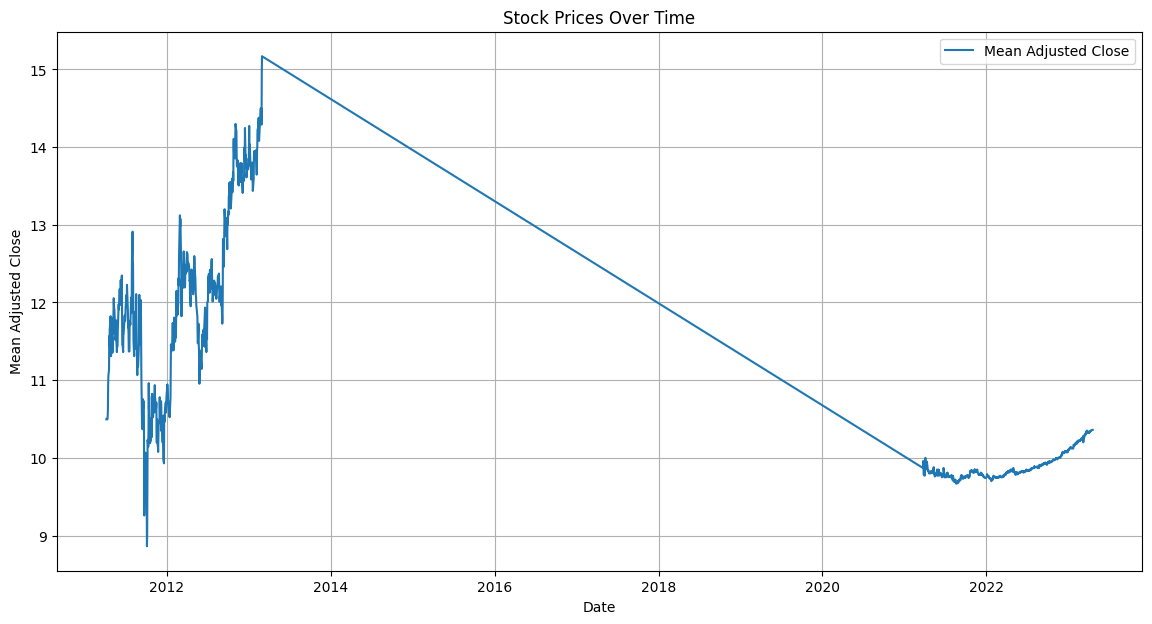

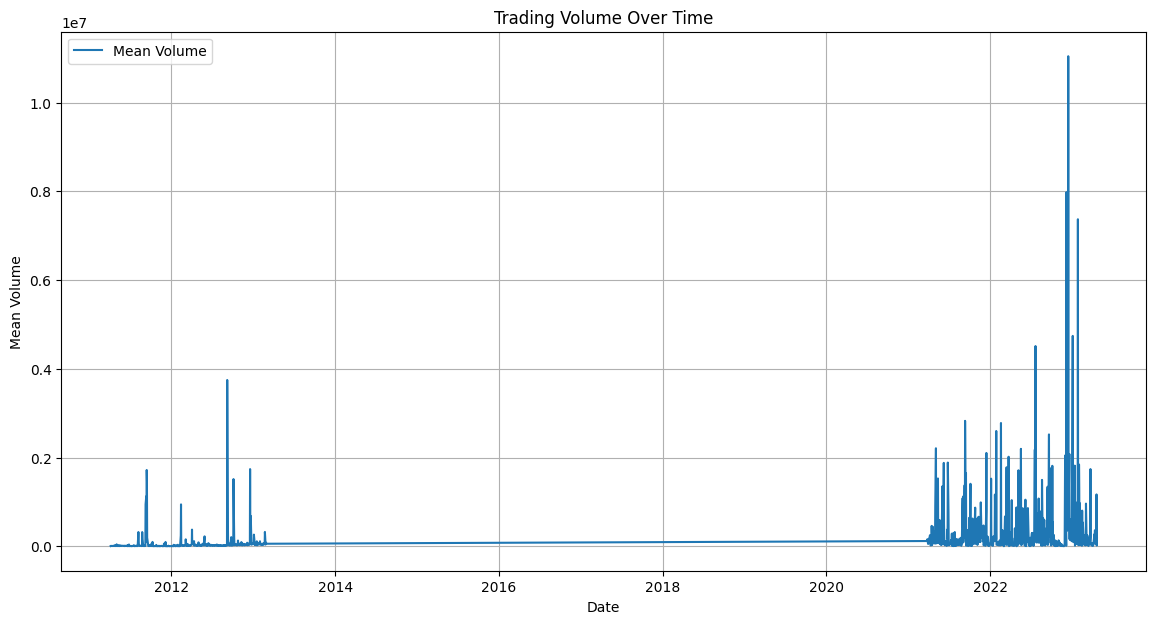

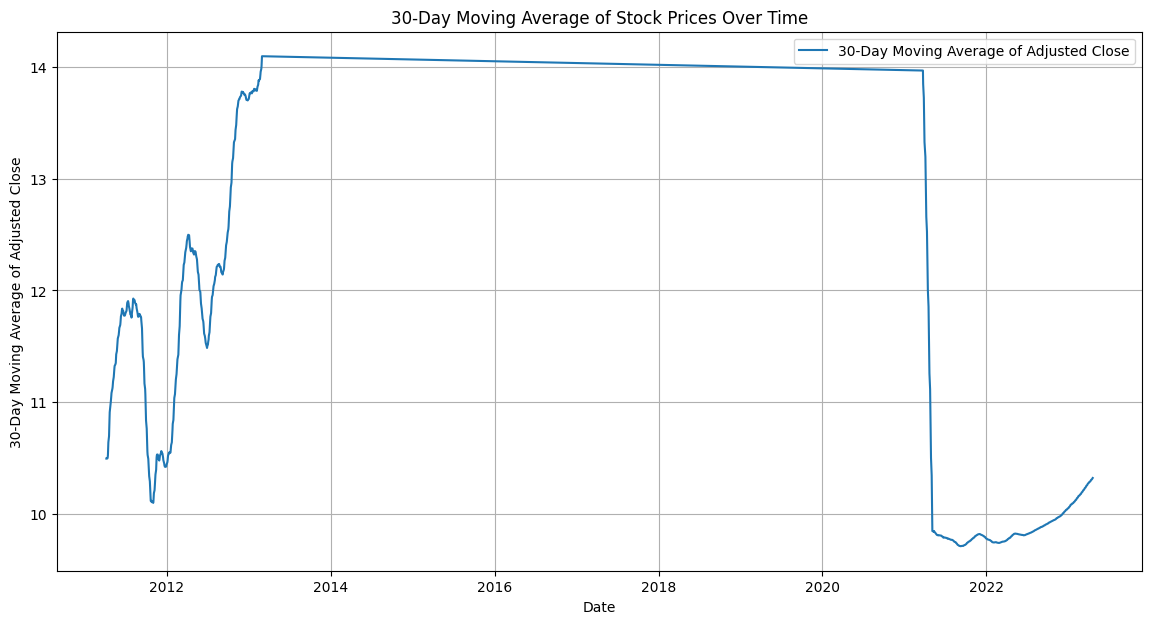

In [50]:
df = df.withColumn("Date", col("Date").cast("date"))

# Group by date and calculate mean of 'adjclose' and 'volume'
daily_df = df.groupBy("Date").agg(mean("adjclose").alias("mean_adjclose"), mean("volume").alias("mean_volume"))

# Collect data for plotting
daily_data = daily_df.orderBy("Date").collect()
dates = [row["Date"] for row in daily_data]
mean_adjclose = [row["mean_adjclose"] for row in daily_data]
mean_volume = [row["mean_volume"] for row in daily_data]

# Plotting stock prices over time
plt.figure(figsize=(14, 7))
plt.plot(dates, mean_adjclose, label='Mean Adjusted Close')
plt.xlabel('Date')
plt.ylabel('Mean Adjusted Close')
plt.title('Stock Prices Over Time')
plt.legend()
plt.grid(True)
plt.show()

# Plotting trading volume over time
plt.figure(figsize=(14, 7))
plt.plot(dates, mean_volume, label='Mean Volume')
plt.xlabel('Date')
plt.ylabel('Mean Volume')
plt.title('Trading Volume Over Time')
plt.legend()
plt.grid(True)
plt.show()

# Moving Averages
daily_df = daily_df.withColumn("moving_avg_adjclose", expr("avg(mean_adjclose) OVER (ORDER BY Date ROWS BETWEEN 29 PRECEDING AND CURRENT ROW)"))

# Collect data for plotting
daily_data_moving_avg = daily_df.orderBy("Date").collect()
moving_avg_adjclose = [row["moving_avg_adjclose"] for row in daily_data_moving_avg]

# Plotting moving average of stock prices
plt.figure(figsize=(14, 7))
plt.plot(dates, moving_avg_adjclose, label='30-Day Moving Average of Adjusted Close')
plt.xlabel('Date')
plt.ylabel('30-Day Moving Average of Adjusted Close')
plt.title('30-Day Moving Average of Stock Prices Over Time')
plt.legend()
plt.grid(True)
plt.show()


# Plotiing Graphs to check the trend of Mean values

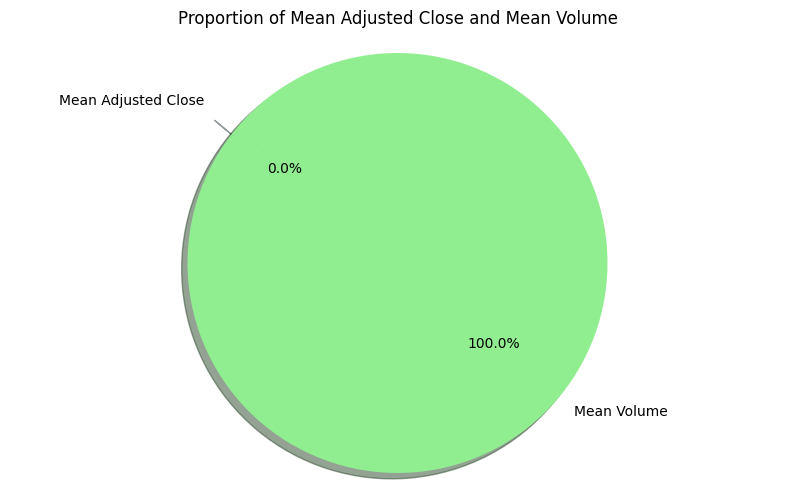

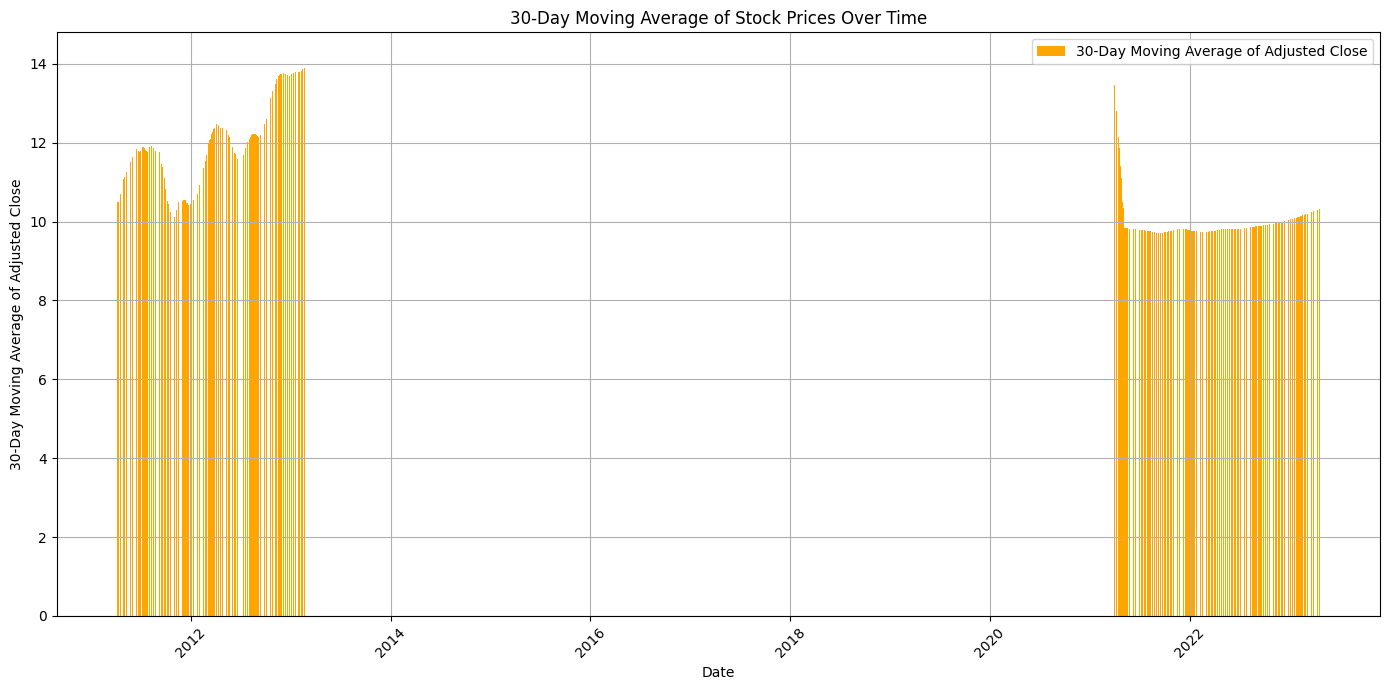

In [60]:

labels = ['Mean Adjusted Close', 'Mean Volume']
sizes = [daily_df.select("mean_adjclose").agg({"mean_adjclose": "sum"}).collect()[0][0],
         daily_df.select("mean_volume").agg({"mean_volume": "sum"}).collect()[0][0]]
colors = ['lightblue', 'lightgreen']
explode = (0.1, 0)  

plt.figure(figsize=(10, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')
plt.title('Proportion of Mean Adjusted Close and Mean Volume')
plt.show()

plt.figure(figsize=(14, 7))
plt.bar(dates, moving_avg_adjclose, label='30-Day Moving Average of Adjusted Close', color='orange')
plt.xlabel('Date')
plt.ylabel('30-Day Moving Average of Adjusted Close')
plt.title('30-Day Moving Average of Stock Prices Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Checking Corelation using Confusion Matrix and Graph

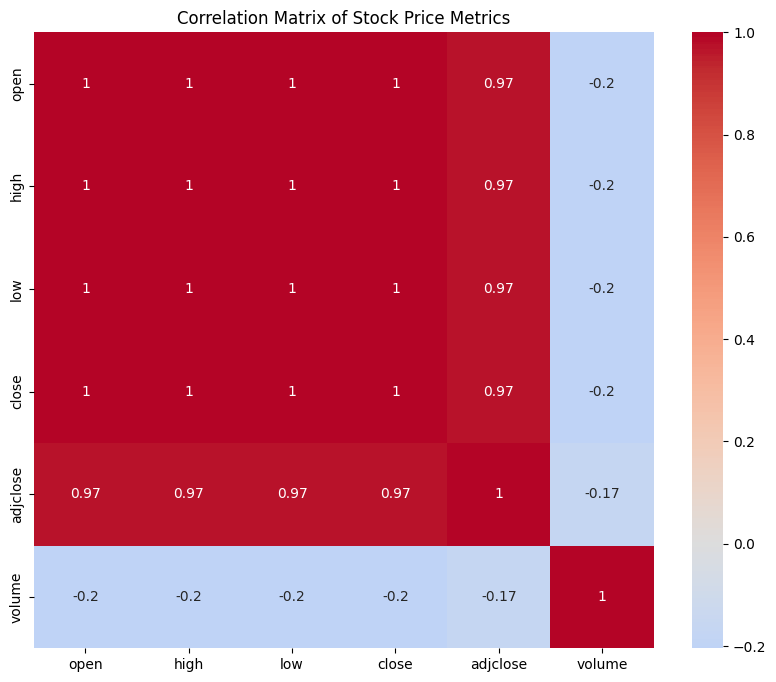

In [51]:

correlation_matrix = df.select(numerical_columns).toPandas().corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Stock Price Metrics')
plt.show()


# Feature Engineering and Model Training

In [52]:
windowSpec = Window.orderBy("Date").rowsBetween(-29, 0)
df = df.withColumn("30d_avg_volume", avg("volume").over(windowSpec))

@udf(DoubleType())
def calculate_rsi(close_prices):
    delta = close_prices[-1] - close_prices[0]
    gains = sum([close_prices[i + 1] - close_prices[i] for i in range(len(close_prices) - 1) if close_prices[i + 1] > close_prices[i]])
    losses = -sum([close_prices[i + 1] - close_prices[i] for i in range(len(close_prices) - 1) if close_prices[i + 1] < close_prices[i]])
    avg_gain = gains / 14
    avg_loss = losses / 14
    if avg_loss == 0:
        rs = 0
    else:
        rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi
rsi_window = Window.orderBy("Date").rowsBetween(-13, 0)
df = df.withColumn("close_prices", collect_list("close").over(rsi_window))
df = df.withColumn("rsi", calculate_rsi(col("close_prices")))

feature_cols = ['open', 'high', 'low', 'close', 'adjclose', 'volume', '30d_avg_volume', 'rsi']
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)

lr = LinearRegression(featuresCol='scaled_features', labelCol='adjclose', predictionCol='prediction')

pipeline = Pipeline(stages=[assembler, scaler, lr])

(train_data, test_data) = df.randomSplit([0.8, 0.2], seed=42)

model = pipeline.fit(train_data)

predictions = model.transform(test_data)

evaluator = RegressionEvaluator(labelCol='adjclose', predictionCol='prediction', metricName='rmse')
rmse = evaluator.evaluate(predictions)
print("Root Mean Squared Error (RMSE) on test data:", rmse)



Root Mean Squared Error (RMSE) on test data: 8.701557551100177e-13


# Hyper Tuning Model

In [53]:

param_grid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1, 0.5]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

evaluator = RegressionEvaluator(labelCol='adjclose', predictionCol='prediction', metricName='rmse')

cross_validator = CrossValidator(estimator=pipeline,
                                 estimatorParamMaps=param_grid,
                                 evaluator=evaluator,
                                 numFolds=3)  
cv_model = cross_validator.fit(train_data)

predictions = cv_model.transform(test_data)

rmse = evaluator.evaluate(predictions)
print("Root Mean Squared Error (RMSE) on test data after hyperparameter tuning:", rmse)


Root Mean Squared Error (RMSE) on test data after hyperparameter tuning: 0.009847448781337354


# Performing Sentiment Analysis on the Column Ticker

In [55]:
sid = SentimentIntensityAnalyzer()

def vader_sentiment_analysis(text):
    return sid.polarity_scores(str(text))['compound']

vader_sentiment_udf = udf(vader_sentiment_analysis, DoubleType())

df_with_sentiment = df.withColumn("ticker_sentiment_score", vader_sentiment_udf(col("ticker")))

 # here im assigning categories
def get_sentiment_label(score):
    score = float(score)
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"
sentiment_label_udf = udf(get_sentiment_label)


df_with_sentiment = df_with_sentiment.withColumn("ticker_sentiment_label", sentiment_label_udf(col("ticker_sentiment_score")))

df_with_sentiment.select("ticker", "ticker_sentiment_score", "ticker_sentiment_label").show(truncate=False)





+------+----------------------+----------------------+
|ticker|ticker_sentiment_score|ticker_sentiment_label|
+------+----------------------+----------------------+
|AAC   |0.0                   |Neutral               |
|AAC   |0.0                   |Neutral               |
|AAC   |0.0                   |Neutral               |
|AAC   |0.0                   |Neutral               |
|AAC   |0.0                   |Neutral               |
|AAC   |0.0                   |Neutral               |
|AAC   |0.0                   |Neutral               |
|AAC   |0.0                   |Neutral               |
|AAC   |0.0                   |Neutral               |
|AAC   |0.0                   |Neutral               |
|AAC   |0.0                   |Neutral               |
|AAC   |0.0                   |Neutral               |
|AAC   |0.0                   |Neutral               |
|AAC   |0.0                   |Neutral               |
|AAC   |0.0                   |Neutral               |
|AAC   |0.

# Graphical Analysis of the Sentiments using Box Plot

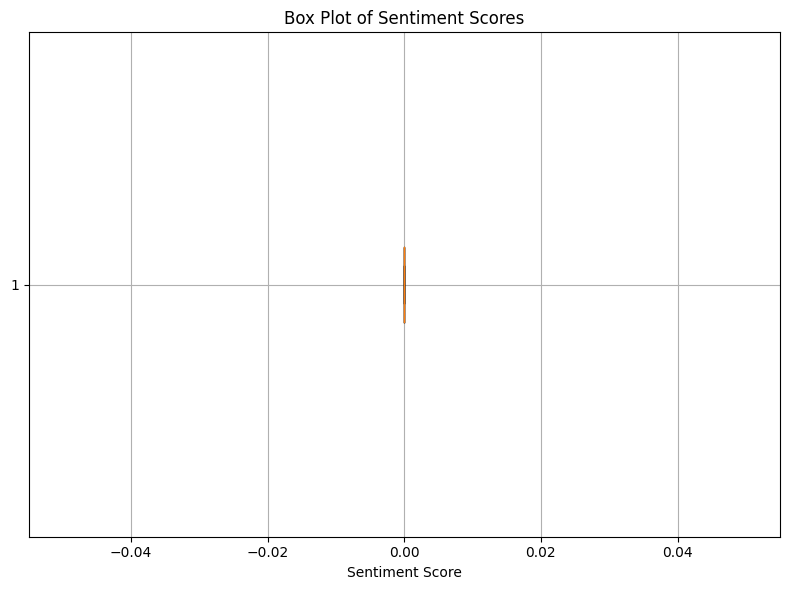

In [62]:

sentiment_scores = df_with_sentiment.select("ticker_sentiment_score").toPandas()

plt.figure(figsize=(8, 6))
plt.boxplot(sentiment_scores["ticker_sentiment_score"], vert=False)
plt.title('Box Plot of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.grid(True)
plt.tight_layout()
plt.show()


# Word Cloud of Sentimrnt Analysis

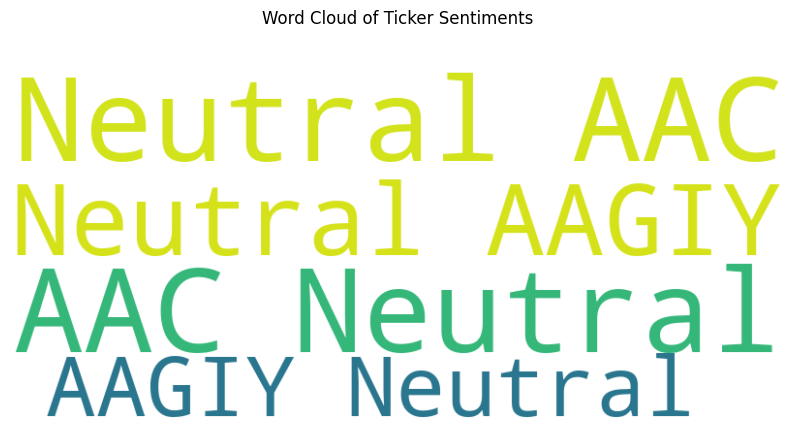

In [68]:

ticker_sentiments_list = df_with_sentiment.select("ticker","ticker_sentiment_label").rdd.flatMap(lambda x: x).collect()

sentiments_text = ' '.join(ticker_sentiments_list)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(sentiments_text)

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud of Ticker Sentiments')
plt.axis('off')
plt.show()


# Descriptive Statistics (This was our Initial test on the whole dataset but due to session problems we reduces its size afterward)

In [ ]:
summary = df.describe().show()

median_df = df.approxQuantile(numerical_columns, [0.5], 0.01)
median_dict = {numerical_columns[i]: median_df[i][0] for i in range(len(numerical_columns))}

print("Median values:")
print(median_dict)

# Identify outliers using IQR
for column in numerical_columns:
    q1, q3 = df.approxQuantile(column, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df.filter((col(column) < lower_bound) | (col(column) > upper_bound))
    print(f"Outliers in column {column}:")
    outliers.show()


+-------+-------------------+-------------------+-------------------+------------------+-------------------+--------------------+-------+
|summary|               open|               high|                low|             close|           adjclose|              volume| ticker|
+-------+-------------------+-------------------+-------------------+------------------+-------------------+--------------------+-------+
|  count|            5430390|            5430390|            5430390|           5430390|            5430390|             5430390|5430390|
|   mean|  770932.9102140031|  797617.2955442839|  738540.9281077606| 765622.8822486014|  765606.7244855547|  2909108.5174652347|   NULL|
| stddev|5.499114396908013E7|5.670131301585984E7|5.286940979594585E7|5.46444890117639E7|5.464448920503336E7|2.1156609783677608E7|   NULL|
|    min|                0.0| 0.0010000000474974| 0.0010000000474974|0.0010000000474974| 0.0010000000474974|                 0.0|      A|
|    max|      9.960937472E9|    1